 Implement Best-First Search traversal for the given graph starting from node 'A'.

Best-First Search Traversal (List): ['A', 'C', 'F', 'B', 'E', 'D']
Best-First Search Traversal (Path): A -> C -> F -> B -> E -> D

   Traversal
0         A
1         C
2         F
3         B
4         E
5         D


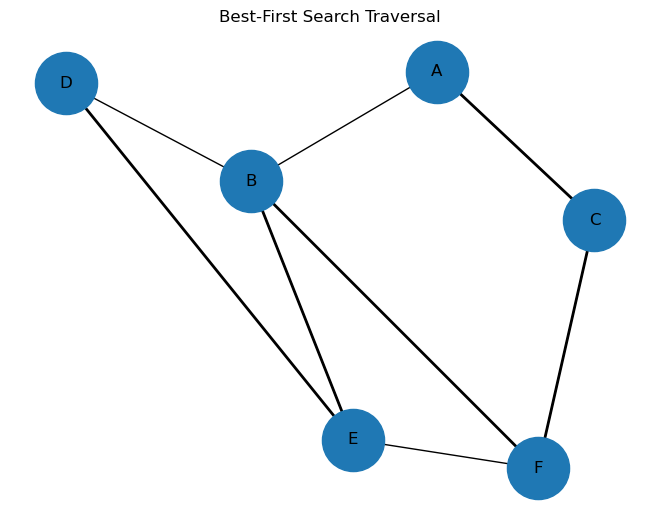

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import heapq


print(" Implement Best-First Search traversal for the given graph starting from node 'A'.")


graph = {
    'A': [('B', 1), ('C', 4)],
    'B': [('D', 2), ('E', 5)],
    'C': [('F', 1)],
    'D': [],
    'E': [('F', 1)],
    'F': []
}


heuristic = {
    'A': 6,
    'B': 4,
    'C': 2,
    'D': 3,
    'E': 1,
    'F': 0
}

def best_first_search(graph, start):
    visited = []
    priority_queue = []

    heapq.heappush(priority_queue, (heuristic[start], start))

    while priority_queue:
        h, node = heapq.heappop(priority_queue)

        if node not in visited:
            visited.append(node)

            for neighbor, cost in graph[node]:
                if neighbor not in visited:
                    heapq.heappush(priority_queue,
                                   (heuristic[neighbor], neighbor))

    return visited

result = best_first_search(graph, 'A')

arrow_path = " -> ".join(result)

print("\nBest-First Search Traversal (List):", result)
print("Best-First Search Traversal (Path):", arrow_path)

print("\n", pd.DataFrame(result, columns=["Traversal"]))

G = nx.Graph([(u, v) for u in graph for v, c in graph[u]])
pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True, node_size=2000)

nx.draw_networkx_edges(
    G, pos,
    edgelist=[(result[i], result[i+1])
              for i in range(len(result)-1)],
    width=2
)

plt.title("Best-First Search Traversal")
plt.show()